Running DIffuction text-to-image pipeline

In [15]:
import os
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
devise = 'cuda' if torch.cuda.is_available() else device
print(f"Using device: {devise}")

Using device: mps


Get the pipeline

In [16]:
pipe = StableDiffusionPipeline.from_pretrained(
	"runwayml/stable-diffusion-v1-5",
	use_auth_token=True
).to(device)
print("pipeline loaded")

pipeline loaded


Visualize the pipeline

In [3]:
print(pipe)

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}



In [9]:
from torchinfo import summary

summary(pipe.unet, input_data=(latent, t, emb))

Layer (type:depth-idx)                                            Output Shape              Param #
UNet2DConditionModel                                              [1, 4, 64, 64]            --
├─Timesteps: 1-1                                                  [1, 320]                  --
├─TimestepEmbedding: 1-2                                          [1, 1280]                 --
│    └─Linear: 2-1                                                [1, 1280]                 410,880
│    └─SiLU: 2-2                                                  [1, 1280]                 --
│    └─Linear: 2-3                                                [1, 1280]                 1,639,680
├─Conv2d: 1-3                                                     [1, 320, 64, 64]          11,840
├─ModuleList: 1-4                                                 --                        --
│    └─CrossAttnDownBlock2D: 2-4                                  [1, 320, 32, 32]          --
│    │    └─ModuleList: 3-3  

Generate image

  0%|          | 0/50 [00:00<?, ?it/s]

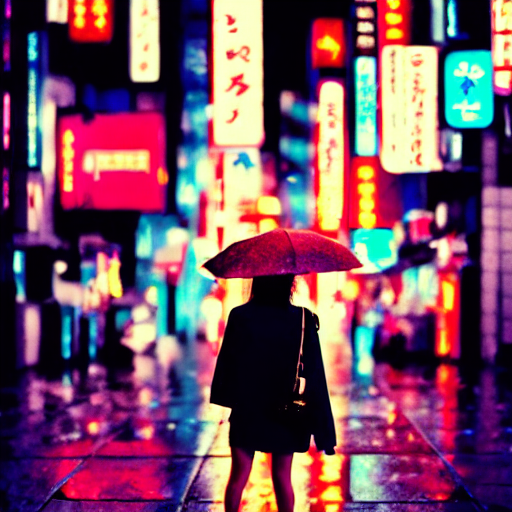

In [14]:
prompt = ("a cinematic portrait of a young woman standing in a rainy neon-lit street in Tokyo "
		  "at night, wet pavement reflecting colorful lights, shallow depth of field, "
		  "35mm photography, ultra detailed, soft lighting, bokeh, high contrast, "
		  "realistic skin texture, masterpiece, best quality")

image = pipe(prompt)[0][0]
display(image)

  0%|          | 0/50 [00:00<?, ?it/s]

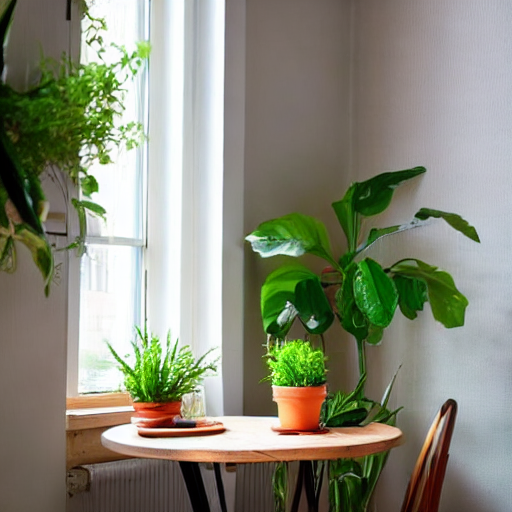

In [17]:
prompt = ("den table with a steaming cup of coffee,"
" a few green plants on the windowsill, "
"soft and warm lighting, simple and realistic style)")

image = pipe(prompt)[0][0]
display(image)